# Autores

### Julio Lucero / julio.lucero@alumnos.upm.es
### Agostina Squillari / ma.squillari@alumnos.upm.es

In [1]:
import imageio as iio
import numpy as np
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D as ax3d
%matplotlib inline

/var/folders/xc/p7wlz0j52ljblkz__vjkjkn00000gn/T/ipykernel_20600/157310912.py:2: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  imNp = iio.imread('imagen_original.png')
/var/folders/xc/p7wlz0j52ljblkz__vjkjkn00000gn/T/ipykernel_20600/157310912.py:3: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  markImg = iio.imread('imagen_marcada.png')


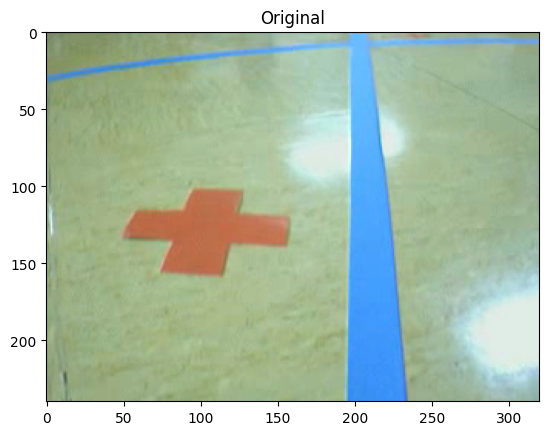

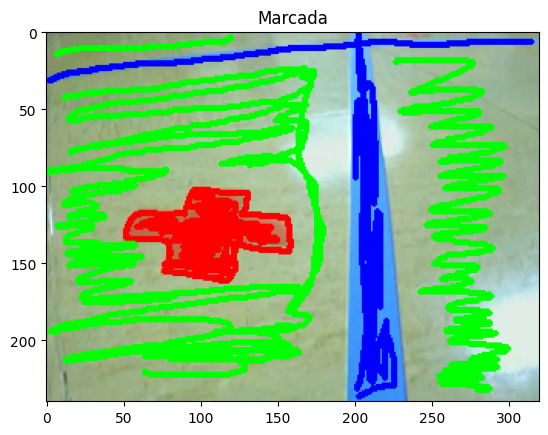

In [2]:
# Leo las imagenes de entrenamiento
imNp = iio.imread('imagen_original.png')
markImg = iio.imread('imagen_marcada.png')

plt.imshow(imNp)
plt.title("Original")
plt.show()

plt.imshow(markImg)
plt.title("Marcada")
plt.show()

In [3]:
# Almaceno los valores RGB de 'imNp' que fuero marcados en 'markImg' en rojo verde y azul
# Creamos máscaras para encontrar dónde pintaste cada color puro
mask_marca = (markImg[:,:,0] == 255) & (markImg[:,:,1] == 0) & (markImg[:,:,2] == 0)
mask_fondo = (markImg[:,:,0] == 0) & (markImg[:,:,1] == 255) & (markImg[:,:,2] == 0)
mask_linea = (markImg[:,:,0] == 0) & (markImg[:,:,1] == 0) & (markImg[:,:,2] == 255)

# Almaceno los valores RGB de 'imNp' que fueron marcados
data_marca = imNp[mask_marca] # datos marcados en rojo
data_fondo = imNp[mask_fondo] # datos marcados en verde
data_linea = imNp[mask_linea] # datos marcados en azul

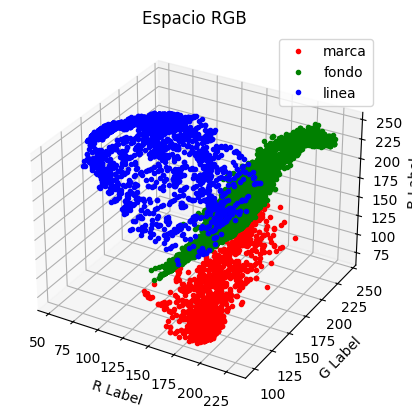

In [4]:
# Pinto los datos RGB
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

ax.plot(data_marca[:,0], data_marca[:,1], data_marca[:,2], 'r.', label='marca')
ax.plot(data_fondo[:,0], data_fondo[:,1], data_fondo[:,2], 'g.', label='fondo')
ax.plot(data_linea[:,0], data_linea[:,1], data_linea[:,2], 'b.', label='linea')
ax.set_xlabel('R Label')
ax.set_ylabel('G Label')
ax.set_zlabel('B Label')
ax.legend()
plt.title('Espacio RGB')
plt.show()

In [5]:
# Ahora hago lo mismo con los datos normalizados segun la 'normalizacion rgb'
# Sumo los canales R, G y B. Añado un valor mínimo para evitar dividir por 0 si hay píxeles negros puros.
suma_rgb = np.sum(imNp, axis=2, keepdims=True).astype(float)
imrgbn = imNp.astype(float) / np.maximum(suma_rgb, 1.0) 

# Reutilizamos las máscaras del paso 3 para extraer los colores ahora normalizados
data_marca_n = imrgbn[mask_marca] # datos marcados en rojo
data_fondo_n = imrgbn[mask_fondo] # datos marcados en verde
data_linea_n = imrgbn[mask_linea] # datos marcados en azul

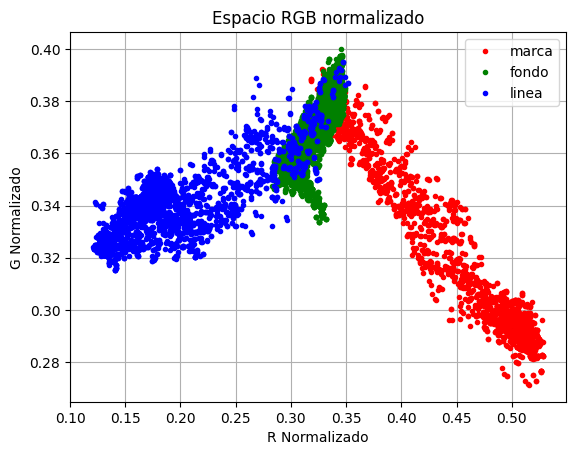

In [6]:
plt.figure()
plt.plot(data_marca_n[:,0], data_marca_n[:,1], 'r.', label='marca')
plt.plot(data_fondo_n[:,0], data_fondo_n[:,1], 'g.', label='fondo')
plt.plot(data_linea_n[:,0], data_linea_n[:,1], 'b.', label='linea')
plt.title('Espacio RGB normalizado')
plt.xlabel('R Normalizado')
plt.ylabel('G Normalizado')
plt.legend()
plt.grid(True)
plt.show()

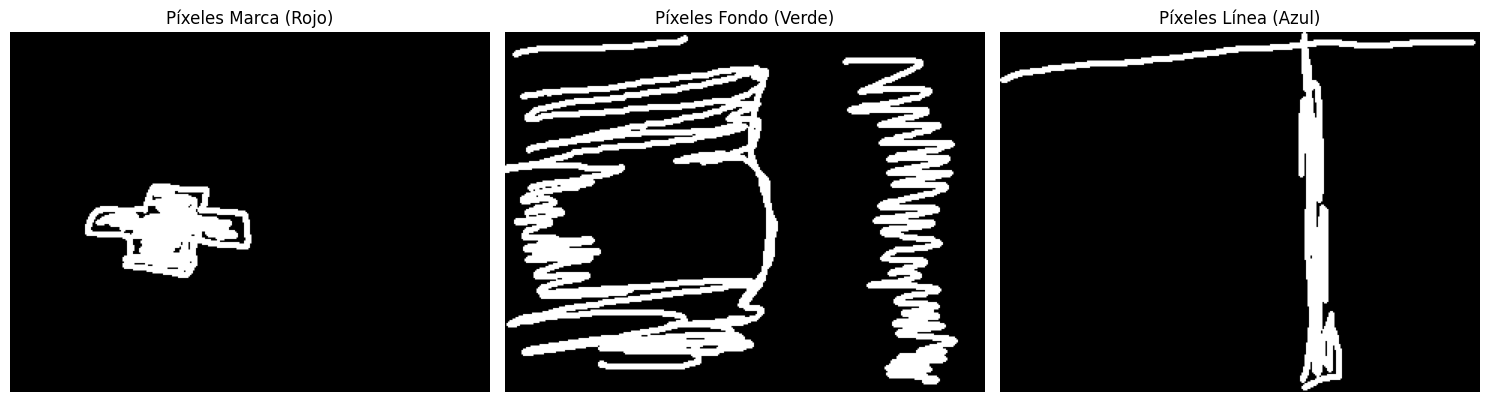

In [ ]:
def mostrar_pixeles_seleccionados(markImg):
    
    # Creamos las máscaras lógicas (True donde coincide el color exacto)
    mask_marca = (markImg[:,:,0] == 255) & (markImg[:,:,1] == 0) & (markImg[:,:,2] == 0)
    mask_fondo = (markImg[:,:,0] == 0) & (markImg[:,:,1] == 255) & (markImg[:,:,2] == 0)
    mask_linea = (markImg[:,:,0] == 0) & (markImg[:,:,1] == 0) & (markImg[:,:,2] == 255)

    # Configuramos la visualización de las 3 imágenes
    # Usamos cmap='gray' para que los True se vean blancos y los False negros
    fig, axs = plt.subplots(1, 3, figsize=(15, 5))

    axs[0].imshow(mask_marca, cmap='gray')
    axs[0].set_title('Píxeles Marca (Rojo)')
    axs[0].axis('off')

    axs[1].imshow(mask_fondo, cmap='gray')
    axs[1].set_title('Píxeles Fondo (Verde)')
    axs[1].axis('off')

    axs[2].imshow(mask_linea, cmap='gray')
    axs[2].set_title('Píxeles Línea (Azul)')
    axs[2].axis('off')

    plt.tight_layout()
    plt.show()

# Llamamos a la función pasándole la imagen que acabamos de cargar
mostrar_pixeles_seleccionados(markImg)